Idea:

learn TruncatedSvd of either dislike vs like (some rating threshold), or maybe -1 and 1 for incorporating seen vs. hasn't seen
    For different numbers of components (could look as function of n components and compute max once), 
        see how well it can reconstruct the like vs. dislike, and maybe seen vs not seen. could maybe
            also have two separate binary matrices, seen vs not seen and like vs not like
                For our simple spotify one it's only seen vs. not seen
                
                
            Anyways, basically sample some (k) users, and check the accuracy (or some other loss metric, but accuracy
                is probably fine)
                
            Goal is finding the minimum number of components that gets a reasonable accuracy

TODO: can't test this with spotify, but could test with movie lens: does doing -1, 0, 1 (zeros implicit / sparse), work 
    better than just 0, 1 saw vs. since saw

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("../")

In [3]:
from ease_recommender import *
from npmi_recommender import *

import pickle as p

In [4]:
def create_mat(row, col, bool_to_int=True):
    # bool_to_int won't count duplicates in the same row, creates a different weighting basically
    if bool_to_int:
        data = np.ones_like(row, dtype=bool)
        return csr_matrix((data, (row, col))).astype(np.int64)
    else:
        data = np.ones_like(row, dtype=np.int64)
        return csr_matrix((data, (row, col)))

def check_if_all_terms_in_str(q, terms):
    for term in terms:
        if term not in q:
            return False

    return True

def get_cat2idx(category_type, D):
    if category_type == "track":
        return D["track2idx"]
    elif category_type == "album":
        return D["album2idx"]
    elif category_type == "artist":
        return D["artist2idx"]
    else:
        raise NotImplementedError

def find_match_using_terms(terms, cat2idx):
    matches = []
    for name in cat2idx.keys():
        if check_if_all_terms_in_str(name, terms):
            matches.append(name)

    if len(matches) > 1:
        raise Exception("Multiple matches found, filter down to a single match", matches)

    return matches[0]

In [5]:
print("loading cache data...")
D = p.load(open("cached_data/spotify_preprocessed.p", "rb"))

print("building csr matrices...")

# TODO: finish implementing track and album level recommendations

# track_mat = create_mat(D["playlist_indices"], D["track_indices"])
# album_mat = create_mat(D["playlist_indices"], D["album_indices"])
artist_mat = create_mat(D["playlist_indices"], D["artist_indices"])

print("done")

loading cache data...
building csr matrices...
done


In [6]:
cat2idx = get_cat2idx("artist", D)
idx2cat = {v:k for k, v in cat2idx.items()}

In [7]:
mat = artist_mat
mat = csr_array(mat)

mat.shape

(1000000, 295860)

In [8]:
from sklearn.decomposition import TruncatedSVD

In [9]:
%%time

svd = TruncatedSVD(128)

X = svd.fit_transform(mat)

CPU times: total: 3min 17s
Wall time: 1min 13s


In [9]:
# import numpy as np
# import warnings

# # Suppress warnings for cleaner output
# # warnings.filterwarnings("ignore")

# class KnowledgeGradientRecommender:
#     def __init__(self, item_embeddings, noise_variance=0.25):
#         """
#         Initialize the recommender.
        
#         Args:
#             item_embeddings (np.ndarray): Matrix of shape (n_items, n_features).
#             noise_variance (float): Assumed variance of the user feedback noise.
#                                     For binary 0/1, 0.25 is a reasonable proxy.
#         """
#         self.X = item_embeddings.astype(np.float64)
#         self.n_items, self.n_features = self.X.shape
#         self.noise_var = noise_variance
        
#         # 1. Initialization (Constraint: Independent Variances)
#         # We start with 0 mean and unit variance for all latent components.
#         self.mu = np.zeros(self.n_features)
        
#         # Diagonal of the covariance matrix (sigma^2_d)
#         # Represents uncertainty for each SVD component.
#         self.sigma_sq = np.ones(self.n_features) 
        
#         # Mask to track seen items
#         self.seen_mask = np.zeros(self.n_items, dtype=bool)

#     def _compute_expected_max_improvement(self, a, b):
#         """
#         Robust version of Algorithm A.
#         Handles parallel lines (duplicate b values) by keeping only the best 'a'.
#         """
#         # 1. Deduplicate Slopes (Handle Parallel Lines)
#         # We sort by b (primary) and a (secondary).
#         # If multiple items have the same 'b', the one with the highest 'a'
#         # will appear LAST in that group.
#         sort_idx = np.lexsort((a, b))
#         a_sorted = a[sort_idx]
#         b_sorted = b[sort_idx]

#         # Create a mask to keep only the *last* occurrence of each unique b value
#         # (which corresponds to the max 'a' for that 'b' due to lexsort).
#         # We use a small epsilon for float comparison stability.
#         diff_b = np.diff(b_sorted)
#         keep_mask = np.concatenate((diff_b > 1e-9, [True]))
        
#         a = a_sorted[keep_mask]
#         b = b_sorted[keep_mask]

#         # If only one line remains, there is no variance/intersection to explore
#         if len(a) < 2:
#             return 0.0

#         # 2. Standard Algorithm A (Convex Hull Scan)
#         # hull indices refer to the 'a' and 'b' arrays we just filtered
#         hull = [0]
        
#         for i in range(1, len(a)):
#             while len(hull) >= 2:
#                 i_prev = hull[-1]
#                 i_prev2 = hull[-2]
                
#                 # Intersection z value between prev and prev2
#                 # Note: b is strictly increasing now, so denominator > 0
#                 z_prev = (a[i_prev] - a[i_prev2]) / (b[i_prev2] - b[i_prev])
                
#                 # Intersection z value between new and prev
#                 z_new = (a[i] - a[i_prev]) / (b[i_prev] - b[i])
                
#                 # If the new intersection is to the left of the old one,
#                 # the middle line (i_prev) is dominated. Pop it.
#                 if z_prev >= z_new:
#                     hull.pop()
#                 else:
#                     break
#             hull.append(i)
            
#         hull = np.array(hull)
#         a_h = a[hull]
#         b_h = b[hull]
        
#         if len(hull) < 2:
#             return 0.0

#         # 3. Integration
#         # Calculate intersections z_k where line k and k+1 meet
#         z = (a_h[:-1] - a_h[1:]) / (b_h[1:] - b_h[:-1])
#         z = np.concatenate(([-np.inf], z, [np.inf]))
        
#         def pdf(x): return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)
#         from scipy.special import ndtr as cdf
        
#         value = 0.0
#         for i in range(len(hull)):
#             # Probability mass in the interval
#             p_mass = cdf(z[i+1]) - cdf(z[i])
            
#             # Expected value of truncated normal in the interval
#             # E[Z | L < Z < U] * P(L < Z < U) = pdf(L) - pdf(U)
#             e_z_term = pdf(z[i]) - pdf(z[i+1])
            
#             value += a_h[i] * p_mass + b_h[i] * e_z_term
            
#         # KG is the Expected Max Improvement over the CURRENT Max
#         # Note: We use the max of the *filtered* a, which is the same as max(original a)
#         current_max = np.max(a)
        
#         return max(0.0, value - current_max)

#     def select_next_item(self):
#         """
#         Calculates the Knowledge Gradient for every unseen item.
#         Returns the index of the item that maximizes Value of Information.
#         """
#         unseen_indices = np.where(~self.seen_mask)[0]
#         if len(unseen_indices) == 0:
#             return None
        
#         X_unseen = self.X[unseen_indices]
        
#         # 1. Pre-calculate 'a' vector (Current Posterior Mean Estimates)
#         # a_i = mu^T x_i
#         a_all = self.X @ self.mu
#         current_max_a = np.max(a_all)
        
#         # 2. Iterate over candidates x_n (the item we might explore)
#         # To compute KG(x_n), we need to see how x_n affects the WHOLE system.
#         kg_scores = []
        
#         # Precompute Sigma * X.T for all items (Diagonal Sigma makes this fast)
#         # Sigma is vector (diagonal), so this is elementwise broadcast
#         # Shape: (n_items, n_features)
#         Sigma_X = self.sigma_sq[None, :] * self.X
        
#         for i, idx in enumerate(tqdm(unseen_indices)):
#             x_candidate = X_unseen[i]
            
#             # Predictive Variance for this candidate: sigma_tilde^2 = x^T Sigma x + noise
#             # Note: self.sigma_sq is a vector (diagonal matrix)
#             # x_candidate^2 * sigma_sq sum
#             pred_var = np.dot(x_candidate**2, self.sigma_sq) + self.noise_var
            
#             # The 'change vector' direction (tilde_sigma in literature)
#             # This is the vector that scales Z to create the new posterior mean.
#             # Delta_mu = (Sigma * x) / sqrt(pred_var) * Z
#             # change_vec shape: (n_features,)
#             change_vec = (x_candidate * self.sigma_sq) / np.sqrt(pred_var)
            
#             # Now we compute 'b' for ALL items (j=1...N) based on candidate x_n
#             # b_j = x_j^T * change_vec
#             b_all = self.X @ change_vec
            
#             # Compute KG value using Algorithm A
#             kg_val = self._compute_expected_max_improvement(a_all, b_all)
#             kg_scores.append(kg_val)
            
#         best_local_idx = np.argmax(kg_scores)
#         return unseen_indices[best_local_idx]

#     def update_belief(self, item_idx, feedback):
#         """
#         Updates the internal embeddings (mu and sigma) based on feedback.
#         Forces the posterior covariance to remain diagonal (Variational approx).
#         """
#         x = self.X[item_idx]
#         y = float(feedback) # 1.0 or 0.0
        
#         # 1. Calculate Standard Linear Gaussian Posterior Mean
#         # posterior_mu = prior_mu + (Sigma x / (x^T Sigma x + noise)) * (y - x^T prior_mu)
        
#         pred_mean = np.dot(x, self.mu)
#         pred_var = np.dot(x**2, self.sigma_sq) + self.noise_var
        
#         kalman_gain = (self.sigma_sq * x) / pred_var
        
#         # Update Mean
#         self.mu = self.mu + kalman_gain * (y - pred_mean)
        
#         # 2. Update Covariance (Diagonal Enforcement)
#         # True update: Sigma_new = Sigma - (Sigma x x^T Sigma) / pred_var
#         # We only keep the diagonal of the update term.
#         # Diagonal element j: (sigma_j^2 * x_j)^2 / pred_var
        
#         covariance_reduction = (self.sigma_sq * x)**2 / pred_var
#         self.sigma_sq = self.sigma_sq - covariance_reduction
        
#         # Mark as seen
#         self.seen_mask[item_idx] = True
        
#         # Optional: Print stats
#         print(f"   -> Updated Belief. Top predicted score: {np.max(self.X @ self.mu):.4f}")

In [10]:
class FastBayesianRecommender:
    def __init__(self, item_embeddings, mu, noise_variance=0.25):
        self.X = item_embeddings.astype(np.float64)
        self.n_items, self.n_features = self.X.shape
        self.noise_var = noise_variance
        
        # Posterior Initialization (0 mean, Unit variance)
#         self.mu = np.zeros(self.n_features)
        self.mu = mu
        self.sigma_sq = np.ones(self.n_features) # Diagonal Covariance
        
        self.seen_mask = np.zeros(self.n_items, dtype=bool)

    def select_next_item_thompson(self):
        """
        Thompson Sampling (TS):
        Samples a realization of the user's preference vector from the current 
        posterior belief, then picks the item that maximizes the score for that sample.
        
        Complexity: O(N) - Just one matrix multiplication.
        """
        unseen_indices = np.where(~self.seen_mask)[0]
        if len(unseen_indices) == 0: return None
        
        X_unseen = self.X[unseen_indices]
        
        # 1. Sample a user vector from the posterior: w ~ N(mu, diag(sigma_sq))
        # Since covariance is diagonal, we sample each component independently.
        sample_w = np.random.normal(
            loc=self.mu, 
            scale=np.sqrt(self.sigma_sq)
        )
        
        # 2. Calculate scores for this sampled world view
        # Score = X * w_sampled
        sampled_scores = X_unseen @ sample_w
        
        # 3. Pick the best item
        best_local_idx = np.argmax(sampled_scores)
        return unseen_indices[best_local_idx]

    def select_next_item_ucb(self, alpha=2.0):
        """
        LinUCB (Upper Confidence Bound):
        Pick item with highest: Mean + alpha * Standard_Deviation
        
        Complexity: O(N) - Very fast vectorized operations.
        alpha: Exploration parameter (higher = more exploration).
        """
        unseen_indices = np.where(~self.seen_mask)[0]
        if len(unseen_indices) == 0: return None
        
        X_unseen = self.X[unseen_indices]
        
        # 1. Calculate Mean scores
        means = X_unseen @ self.mu
        
        # 2. Calculate Predictive Variance for all items
        # Var = x^T Sigma x. Since Sigma is diagonal: sum(x_ij^2 * sigma_j^2)
        # We can vectorize this: (X^2) @ sigma_sq
        # Note: We square X element-wise.
        pred_vars = (X_unseen**2) @ self.sigma_sq
        std_devs = np.sqrt(pred_vars)
        
        # 3. Calculate Upper Confidence Bound
        ucb_scores = means + alpha * std_devs
        
        best_local_idx = np.argmax(ucb_scores)
        return unseen_indices[best_local_idx]

    def update_belief(self, item_idx, feedback):
        """
        Bayesian Linear Regression Update (Diagonal Approximation)
        """
        x = self.X[item_idx]
        y = float(feedback)
        
        pred_mean = np.dot(x, self.mu)
        pred_var = np.dot(x**2, self.sigma_sq) + self.noise_var
        
        # Kalman Gain
        kalman_gain = (self.sigma_sq * x) / pred_var
        
        # Update Mean
        self.mu = self.mu + kalman_gain * (y - pred_mean)
        
        # Update Covariance (Diagonal Variational Approx)
        covariance_reduction = (self.sigma_sq * x)**2 / pred_var
        self.sigma_sq = np.maximum(self.sigma_sq - covariance_reduction, 1e-6)
        
        self.seen_mask[item_idx] = True

In [11]:
import numpy as np
from scipy import sparse

def get_latent_scaling_matrix(svd_model, use_sparse=True):
    """
    Creates the diagonal matrix Sigma from a fitted TruncatedSVD model.
    
    Args:
        svd_model: A fitted sklearn.decomposition.TruncatedSVD object.
        use_sparse (bool): If True, returns a scipy.sparse.dia_matrix. 
                           If False, returns a dense numpy array.
                           
    Returns:
        Sigma (matrix): A diagonal matrix of shape (n_components, n_components)
                        containing the singular values.
    """
    # The singular values (sigma)
    sigmas = svd_model.singular_values_
    n_components = len(sigmas)
    
    if use_sparse:
        # Create a sparse diagonal matrix
        return sparse.diags(sigmas, shape=(n_components, n_components))
    else:
        # Create a dense diagonal matrix
        return np.diag(sigmas)

def extract_item_embeddings(svd_model, scale_by_singular_values=True):
    """
    Extracts item embeddings correctly formatted for the Knowledge Gradient Recommender.
    
    Args:
        svd_model: Fitted SVD model (trained on User x Item matrix).
        scale_by_singular_values (bool): If True, weighs features by their importance.
        
    Returns:
        item_embeddings (np.ndarray): Shape (n_items, n_features)
    """
    # 1. Get the components (V^T) from SVD. Shape: (n_features, n_items)
    #    Note: In User-Item SVD, components_ corresponds to Items.
    raw_components = svd_model.components_
    
    if scale_by_singular_values:
        # Construct Sigma
        sigma_matrix = get_latent_scaling_matrix(svd_model, use_sparse=False)
        
        # Apply scaling: Sigma * V^T
        # We do this because we want the features to carry the weight of their variance.
        scaled_components = np.dot(sigma_matrix, raw_components)
        
        # Transpose to get (n_items, n_features) as required by the Recommender
        return scaled_components.T
    else:
        # Just transpose V^T -> V
        return raw_components.T

In [18]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412


In [21]:
n_items = mat.shape[1]

x = np.zeros(n_items, dtype=bool)
x[a] = True

y = svd.transform(x[None, :])[0]

In [22]:
from scipy import sparse
# Creates a sparse n x n identity matrix
matrix = sparse.eye(n_items, format='csr')

In [23]:
Y = svd.transform(matrix)

In [24]:
assert np.allclose(Y[a], y)

In [31]:
recommender = FastBayesianRecommender(Y, y)
    
print(f"Starting Optimal Exploration (KG) over {n_items} items.")
print("-------------------------------------------------------")

for step in range(100): # Ask 10 questions
    # Select best item to explore
    print(f"\nStep {step+1}: Calculating Knowledge Gradient...")
    item_idx = recommender.select_next_item_thompson()
    
    response = input(f"Do you like this: {idx2cat[item_idx]}").lower()
    
    assert "q" not in response
    
    assert "y" in response or "n" in response
    assert not ("y" in response and "n" in response)
    
    observed = "y" in response
    
    print("response:", observed)
    
    mu_old = recommender.mu
    recommender.update_belief(item_idx, observed)
    mu_new = recommender.mu
    
    print(f"diff: {np.linalg.norm(mu_old - mu_new)}")
#         if item_idx is None:
#             print("No more items to explore.")
#             break
            
#         # Simulate User Interaction
#         # (Replace this block with actual `input()` in production)
#         raw_score = np.dot(items[item_idx], true_user_pref)
#         prob = 1 / (1 + np.exp(-raw_score * 5)) # Sigmoid probability
#         observed = 1 if np.random.rand() < prob else 0
        
#         print(f"Recommender asks: Have you seen Item {item_idx}?")
#         print(f"User says: {'YES (Liked/Seen)' if observed else 'NO'}")
        
#         # Update model
#         recommender.update_belief(item_idx, observed)

Starting Optimal Exploration (KG) over 295860 items.
-------------------------------------------------------

Step 1: Calculating Knowledge Gradient...
Do you like this: Ariana Grande (spotify:artist:66CXWjxzNUsdJxJ2JdwvnR)y
response: True
diff: 0.8194514915038598

Step 2: Calculating Knowledge Gradient...
Do you like this: Lil Wayne (spotify:artist:55Aa2cqylxrFIXC767Z865)n
response: False
diff: 0.0037393324260120574

Step 3: Calculating Knowledge Gradient...
Do you like this: Snoop Dogg (spotify:artist:7hJcb9fa4alzcOq3EaNPoG)n
response: False
diff: 0.010424923078926883

Step 4: Calculating Knowledge Gradient...
Do you like this: Bruno Mars (spotify:artist:0du5cEVh5yTK9QJze8zA0C)y
response: True
diff: 0.8039610861930375

Step 5: Calculating Knowledge Gradient...
Do you like this: Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4)n
response: False
diff: 0.0013961366157815378

Step 6: Calculating Knowledge Gradient...
Do you like this: Childish Gambino (spotify:artist:73sIBHcqh3Z3NyqHKZ7FOL)n

Do you like this: Michael Jackson (spotify:artist:3fMbdgg4jU18AjLCKBhRSm)y
response: True
diff: 0.8849633022678907

Step 54: Calculating Knowledge Gradient...
Do you like this: Sia (spotify:artist:5WUlDfRSoLAfcVSX1WnrxN)y
response: True
diff: 0.755803193351962

Step 55: Calculating Knowledge Gradient...
Do you like this: Jeremih (spotify:artist:3KV3p5EY4AvKxOlhGHORLg)n
response: False
diff: 0.009519895681427006

Step 56: Calculating Knowledge Gradient...
Do you like this: Frank Ocean (spotify:artist:2h93pZq0e7k5yf4dywlkpM)n
response: False
diff: 0.03802874796104245

Step 57: Calculating Knowledge Gradient...
Do you like this: Jason Derulo (spotify:artist:07YZf4WDAMNwqr4jfgOZ8y)n
response: False
diff: 0.07192795225342176

Step 58: Calculating Knowledge Gradient...
Do you like this: The Notorious B.I.G. (spotify:artist:5me0Irg2ANcsgc93uaYrpb)n
response: False
diff: 0.03405953816211022

Step 59: Calculating Knowledge Gradient...
Do you like this: Macklemore & Ryan Lewis (spotify:artist:5B

In [42]:
recommender = FastBayesianRecommender(Y, y, noise_variance=0)
    
print(f"Starting Optimal Exploration (KG) over {n_items} items.")
print("-------------------------------------------------------")

for step in range(100): # Ask 10 questions
    # Select best item to explore
    print(f"\nStep {step+1}: Calculating Knowledge Gradient...")
    item_idx = recommender.select_next_item_thompson()
    
    response = input(f"Do you like this: {idx2cat[item_idx]}").lower()
    
    assert "q" not in response
    
    assert "y" in response or "n" in response
    assert not ("y" in response and "n" in response)
    
    observed = "y" in response
    
    print("response:", observed)
    
    mu_old = recommender.mu
    recommender.update_belief(item_idx, observed)
    mu_new = recommender.mu
    
    print(f"diff: {np.linalg.norm(mu_old - mu_new)}")
#         if item_idx is None:
#             print("No more items to explore.")
#             break
            
#         # Simulate User Interaction
#         # (Replace this block with actual `input()` in production)
#         raw_score = np.dot(items[item_idx], true_user_pref)
#         prob = 1 / (1 + np.exp(-raw_score * 5)) # Sigmoid probability
#         observed = 1 if np.random.rand() < prob else 0
        
#         print(f"Recommender asks: Have you seen Item {item_idx}?")
#         print(f"User says: {'YES (Liked/Seen)' if observed else 'NO'}")
        
#         # Update model
#         recommender.update_belief(item_idx, observed)

Starting Optimal Exploration (KG) over 295860 items.
-------------------------------------------------------

Step 1: Calculating Knowledge Gradient...
Do you like this: Lana Del Rey (spotify:artist:00FQb4jTyendYWaN8pK0wa)n
response: False
diff: 0.0016355896343865925

Step 2: Calculating Knowledge Gradient...
Do you like this: B.o.B (spotify:artist:5ndkK3dpZLKtBklKjxNQwT)y
response: True
diff: 1.127437653421191

Step 3: Calculating Knowledge Gradient...
Do you like this: Kendrick Lamar (spotify:artist:2YZyLoL8N0Wb9xBt1NhZWg)n
response: False
diff: 0.008837575782388928

Step 4: Calculating Knowledge Gradient...
Do you like this: Katy Perry (spotify:artist:6jJ0s89eD6GaHleKKya26X)y
response: True
diff: 1.1112901659744965

Step 5: Calculating Knowledge Gradient...
Do you like this: Nicki Minaj (spotify:artist:0hCNtLu0JehylgoiP8L4Gh)q


AssertionError: 

In [70]:
# Y_alt = extract_item_embeddings(svd)
Y_alt = Y[:, :32]

y_alt = Y_alt[a]

In [71]:
best = np.argsort(np.linalg.norm(Y_alt - y_alt[None, :], axis=-1))
# best = np.argsort(np.linalg.norm(Y - y[None, :], axis=-1))
# best = np.argsort(-svd.inverse_transform(recommender.mu[None, :])[0])

top_k = 100

for i in best[:top_k]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Houses (spotify:artist:648kpaANsUr1HABoE4mkPw)
Motopony (spotify:artist:5urVI6ZUTzPlsqQoHVwc9s)
Typhoon (spotify:artist:6p6WlxIkeWH8yOYvciFfVl)
San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)
Patrick Watson (spotify:artist:7bPs6jf983f0bjRAt1yxDM)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
Son Little (spotify:artist:4lujUKeO6nQAJXpq37Epn7)
S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)
Vancouver Sleep Clinic (spotify:artist:77BznF1Dr1k5KyEZ6Nn3jB)
Conner Youngblood (spotify:artist:1HzpwUIkmmlGCNuoOcXiIW)
Wake Owl (spotify:artist:2lnn5H36McBxbyhPYg10oj)
Sarah Jaffe (spotify:artist:1z2SrszsRmq47kDhBAnyNS)
Bahari (spotify:artist:0fs8oBR1rx7JIXZi75h7Uu)
Fink (spotify:artist:2t9yJDJIEtvPmr2iRIdqBf)
The Album Leaf (spotify:artist:02uPe16VFxPaiueQsPEDkE)
Junip (spotify:artist:7HcipAIJatVG

In [26]:
idx2cat[item_idx]

'Rihanna (spotify:artist:5pKCCKE2ajJHZ9KAiaK11H)'

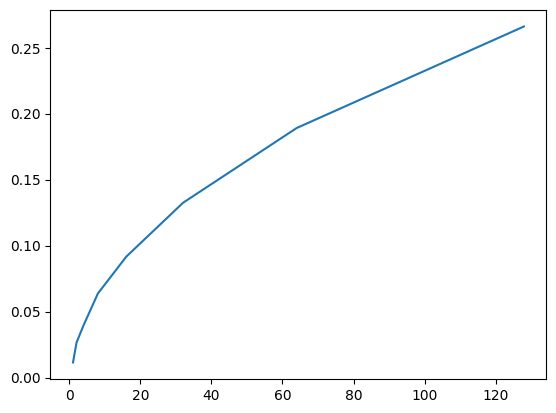

In [95]:
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve, roc_auc_score

np.random.seed(42)

I = np.random.choice(mat.shape[0], size=128)
y_true = np.asarray(mat[I, :].todense(), dtype="bool")

errs = []
err_trues = []
err_falses = []
n_components_to_use = [1, 2, 4, 8, 16, 32, 64, 128]

roc_scores = []

for components_to_use in tqdm(n_components_to_use):
    x = np.copy(X[I])
    
    assert components_to_use >= 1
    assert components_to_use <= 128

    x[:, components_to_use:] = 0

    y = svd.inverse_transform(x)
    y = y >= .5
    
    err = 1 - (y == y_true).mean()
    err_true = 1 - (y[y_true] == y_true[y_true]).mean()
    err_false = 1 - (y[~y_true] == y_true[~y_true]).mean()

    errs.append(err)
    err_trues.append(err_true)
    err_falses.append(err_false)
    
    roc_scores.append(roc_auc_score(np.reshape(y_true, -1), np.reshape(y, -1)))
    
#     print((y[y_true] == y_true[y_true]).mean())

  0%|          | 0/8 [00:00<?, ?it/s]

In [96]:
errs = np.array(errs)
err_trues = np.array(err_trues)
err_falses = np.array(err_falses)
roc_scores = np.array(roc_scores)

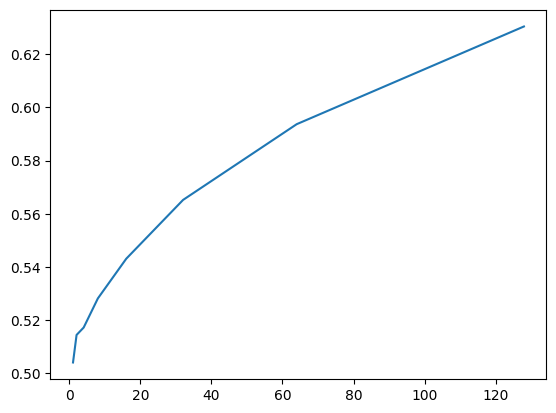

In [102]:
import matplotlib.pyplot as plt

plt.plot(n_components_to_use, roc_scores);

In [98]:
err_trues[-1]

np.float64(0.7390438247011952)

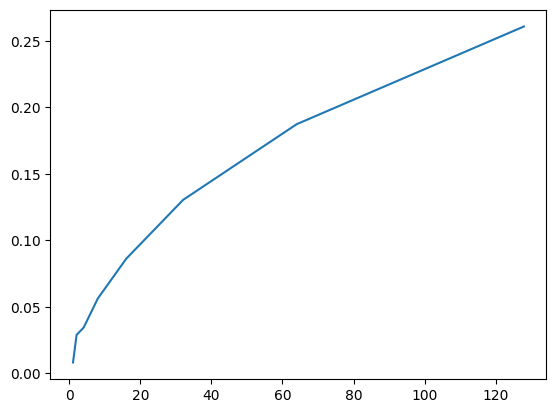

In [99]:
import matplotlib.pyplot as plt

plt.plot(n_components_to_use, 1 - err_trues);

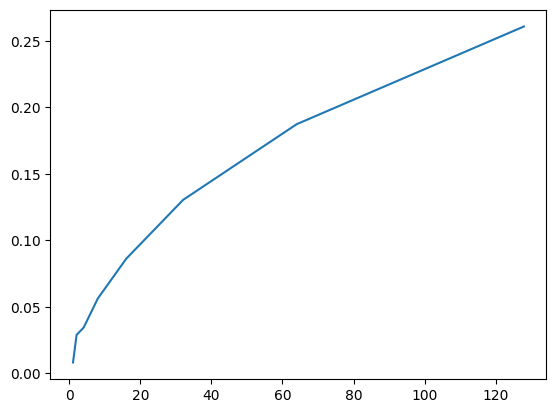

In [100]:
import matplotlib.pyplot as plt

plt.plot(n_components_to_use, 1 - err_trues);

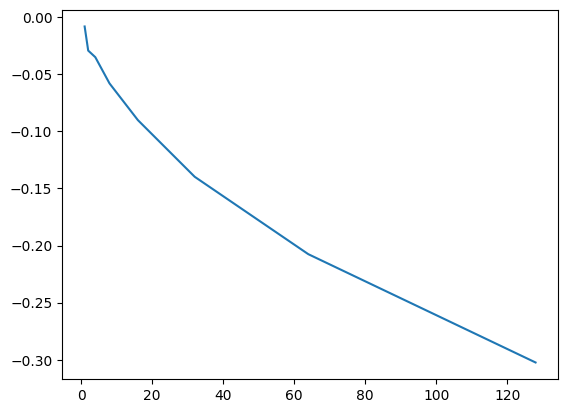

In [101]:
# plt.plot(n_components_to_use, np.log(errs));
plt.plot(n_components_to_use, np.log(err_trues));
# plt.plot(n_components_to_use, np.log(err_falses));

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
roc_auc_score()

In [69]:
np.log(1 - .99)

np.float64(-4.605170185988091)

In [59]:
(y == y_true).mean()

np.float64(0.999875941323599)

In [51]:
(y == y_true).mean()

np.float64(0.9999054620428581)

In [52]:
(y[y_true] == y_true[y_true]).mean()

np.float64(0.2660846460428924)

In [53]:
(y[~y_true] == y_true[~y_true]).mean()

np.float64(0.9999969542610154)

In [ ]:
X = mat.T @ mat

# to convert to probabilities
# X.data /= mat.shape[0]

X.shape

In [29]:
counts = X.diagonal()

keeps = counts >= 128

print("keeps.mean()", keeps.mean())

keep_inds = np.where(keeps)[0]

keeps.mean() 0.05848374231055229


In [30]:
counts[a]

np.int64(1981)

In [31]:
counts[b]

np.int64(412)

In [43]:
X2 = X[:, keep_inds][keep_inds, :].T

In [48]:
%%time

svd = TruncatedSVD(8)

X3 = svd.fit_transform(X2)

CPU times: total: 9.09 s
Wall time: 9.12 s


In [50]:
%%time

svd = TruncatedSVD(16)

X3 = svd.fit_transform(X2)

CPU times: total: 11 s
Wall time: 11.1 s


In [51]:
%%time

svd = TruncatedSVD(32)

X3 = svd.fit_transform(X2)

CPU times: total: 16.4 s
Wall time: 15.3 s


In [52]:
%%time

svd = TruncatedSVD(64)

X3 = svd.fit_transform(X2)

CPU times: total: 26.9 s
Wall time: 23.9 s


In [53]:
%%time

svd = TruncatedSVD(128)

X3 = svd.fit_transform(X2)

CPU times: total: 52.9 s
Wall time: 45.9 s


In [59]:
%%time

from scipy.sparse.linalg import svds

embedding_dim = 128

u, s, vt = svds(X2, k=embedding_dim)

CPU times: total: 2min 13s
Wall time: 2min 12s


In [60]:
# def get_spectral_ease_embeddings(G_sparse, embedding_dim=64, lambda_reg=500.0):
#     """
#     Approximates EASE embeddings using re-weighted SVD.
#     This is extremely fast and scalable.
#     """
#     from scipy.sparse.linalg import svds
    
#     # 1. Standard SVD on the Gram Matrix (Covariance)
#     # u: eigenvectors (item embeddings directions)
#     # s: singular values (variance/popularity)
#     u, s, vt = svds(G_sparse, k=embedding_dim)
    
#     # 2. The "EASE Transformation"
#     # In standard SVD, embeddings are u * sqrt(s).
#     # In EASE, we want to suppress high variance (popularity).
#     # The spectral filter of EASE is roughly 1 / (s + lambda).
    
#     # We re-weight the singular values:
#     # Instead of emphasizing top components, we flatten them based on lambda.
#     # This creates embeddings that are "whitened" relative to popularity.
    
#     weights = s / (s + lambda_reg)
    
#     # 3. Create Embeddings
#     # This creates a low-rank approximation of the EASE weight matrix
#     ease_embeddings = u * weights[None, :]
    
#     return ease_embeddings

In [141]:
def get_spectral_ease_embeddings(u, s, vt, lambda_reg=500.0):
    """
    Approximates EASE embeddings using re-weighted SVD.
    This is extremely fast and scalable.
    """
    
    # 2. The "EASE Transformation"
    # In standard SVD, embeddings are u * sqrt(s).
    # In EASE, we want to suppress high variance (popularity).
    # The spectral filter of EASE is roughly 1 / (s + lambda).
    
    # We re-weight the singular values:
    # Instead of emphasizing top components, we flatten them based on lambda.
    # This creates embeddings that are "whitened" relative to popularity.
    
    weights = s / (s + lambda_reg)
    
    # 3. Create Embeddings
    # This creates a low-rank approximation of the EASE weight matrix
    ease_embeddings = u * weights[None, :]
#     ease_embeddings = u * np.sqrt(weights)[None, :]
    
    return ease_embeddings

In [142]:
components_to_use = 128

ease_embeddings = get_spectral_ease_embeddings(u[:, :components_to_use], s[:components_to_use], vt, lambda_reg=1000000)

Y_alt = ease_embeddings
y_alt = ease_embeddings[keep_inds.tolist().index(a)]

best = keep_inds[np.argsort(np.linalg.norm(Y_alt - y_alt[None, :], axis=-1))]
# best = np.argsort(np.linalg.norm(Y - y[None, :], axis=-1))
# best = np.argsort(-svd.inverse_transform(recommender.mu[None, :])[0])

top_k = 100

for i in best[:top_k]:
    print(idx2cat[i])

Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)
Night Beds (spotify:artist:533wKOfkJylNSi6ntO1wXd)
On An On (spotify:artist:3Topzt1UZCz8GQlP7Zsu0M)
Typhoon (spotify:artist:6p6WlxIkeWH8yOYvciFfVl)
Motopony (spotify:artist:5urVI6ZUTzPlsqQoHVwc9s)
San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)
Cathedrals (spotify:artist:7HIjKw4rHS0MtmV0cqSlpB)
Junip (spotify:artist:7HcipAIJatVGT4U6HQrnFW)
Wake Owl (spotify:artist:2lnn5H36McBxbyhPYg10oj)
Patrick Watson (spotify:artist:7bPs6jf983f0bjRAt1yxDM)
Little Green Cars (spotify:artist:2Vz3AN2wY3xjS2jCaGMVsy)
Stateless (spotify:artist:6msJKphD3VXZPItnztefdH)
Houses (spotify:artist:648kpaANsUr1HABoE4mkPw)
Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)
Active Child (spotify:artist:54KTsBl98buzGkELjGlnuU)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
Wye Oak (spotify:artist:5SjNVG3L9mgWQPsfp1sFDB)
Wildcat! Wildcat! (spotify:artist:75idpsM55NDCel7H06QwKO)
Conner Youngblood (spotify:artist:1Hzp

In [109]:
from scipy.sparse.linalg import factorized, spsolve
import scipy.sparse as sp

def calculate_ease_exact_sparse_solver(G_sparse, lambda_reg=500.0, threshold=1e-4):
    """
    Uses sparse Cholesky/LU to solve exact weights.
    Returns a SPARSE matrix by pruning small values.
    """
    N = G_sparse.shape[0]
    
    # 1. Setup Linear System (A = G + lambda * I)
    # CSC format is often better for arithmetic/inversion
    A = G_sparse + sp.eye(N) * lambda_reg
    A = A.tocsc() 
    
    # 2. Factorize A (Pre-compute the solver)
    # This utilizes the sparsity of A to speed up the solve
    solve_A = factorized(A)
    
    # 3. Solve for P column-by-column (or batch)
    # We solve A * P = I. 
    # To save memory, we don't create full I. We solve for unit vectors.
    
    # NOTE: If N is huge, you cannot hold the result in memory.
    # We will build B iteratively.
    
    row_indices = []
    col_indices = []
    data_values = []
    
    # We need the diagonal of P first to normalize. 
    # Unfortunately, getting the exact diagonal requires solving for all columns 
    # or using advanced estimation. 
    # For 'Exact', we solve all columns.
    
    # This loop is slow in Python. In production, C++ or batched solving is preferred.
    for i in range(N):
        # Create standard basis vector e_i
        e_i = np.zeros(N)
        e_i[i] = 1.0
        
        # Solve A * p_col = e_i
        p_col = solve_A(e_i)
        
        # We need P_ii for normalization
        P_ii = p_col[i]
        
        # Calculate B column i: B_ji = - P_ji / P_ii
        # We process the dense column p_col into sparse format immediately
        
        # Normalize
        b_col = - p_col / P_ii
        b_col[i] = 0.0 # Constraint diag(B) = 0
        
        # Thresholding: Only keep significant weights
        mask = np.abs(b_col) > threshold
        
        # Store indices
        idx = np.where(mask)[0]
        row_indices.extend(idx)
        col_indices.extend([i] * len(idx))
        data_values.extend(b_col[idx])

    # Reconstruct Sparse B
    B_sparse = sp.csc_matrix((data_values, (row_indices, col_indices)), shape=(N, N))
    return B_sparse

In [113]:
%%time

B_sparse = calculate_ease_exact_sparse_solver(X2)

MemoryError: 

In [54]:
%%time

svd = TruncatedSVD(256)

X3 = svd.fit_transform(X2)

KeyboardInterrupt: 

In [49]:
%%time

svd = TruncatedSVD(1)

X3 = svd.fit_transform(X)

CPU times: total: 27.7 s
Wall time: 27.8 s


In [23]:
import matplotlib.pyplot as plt

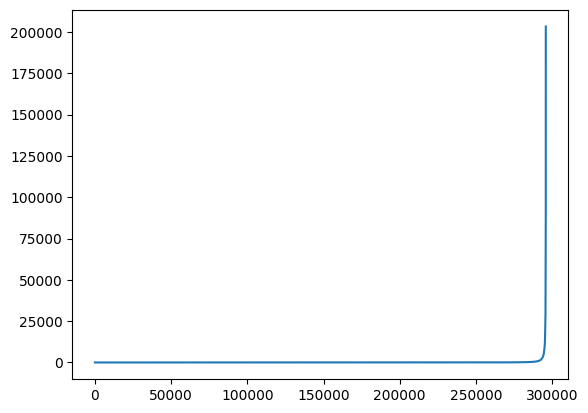

In [24]:
plt.plot(np.sort(counts))

In [27]:
(counts >= 128).mean()

np.float64(0.05848374231055229)

In [ ]:
%%time

svd = TruncatedSVD(128)

X2 = svd.fit_transform(X)

In [ ]:
X2.shape

In [7]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412


In [8]:
import numpy as np
from scipy import sparse

def calculate_pmi_matrix(co_counts, alpha=1.0):
    """
    Calculates Alpha-Smoothed PMI for the entire co-occurrence matrix.
    Only computes values for observed entries (non-zeros) to maintain sparsity.
    
    Formula:
    PMI(x,y) = log( (C_xy + alpha) * N_smoothed / (S_x * S_y) )
             = log(C_xy + alpha) + log(N_smoothed) - log(S_x) - log(S_y)
    
    Args:
        co_counts: (n_items, n_items) scipy.sparse matrix (Counts of x, y).
        alpha: Smoothing parameter.
        
    Returns:
        pmi_matrix: (n_items, n_items) scipy.sparse matrix containing PMI values.
    """
    # Ensure we work with a COO matrix to easily access .row, .col, and .data
    # This is a cheap conversion if it's already CSR/CSC
    co_counts_coo = co_counts.tocoo()
    
    n_items = co_counts_coo.shape[0]
    
    # 1. Global Constants
    # Total sum of all counts in the matrix
    N_raw = co_counts_coo.sum()
    
    # Smoothed Normalization Factor: N + alpha * V^2
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 2. Calculate Smoothed Marginals (S_x and S_y)
    # Row sums gives us C_x (raw marginal counts)
    # We flatten it to a dense 1D array for easy lookup
    C_marginal = np.array(co_counts_coo.sum(axis=1)).flatten()
    
    # Apply smoothing to marginals: C_x + alpha * V
    S_marginal = C_marginal + (alpha * n_items)
    
    # 3. Vectorized PMI Calculation on Non-Zero Elements
    # We operate directly on the 'data' array of the sparse matrix.
    
    # rows and cols indices for every non-zero entry
    rows = co_counts_coo.row
    cols = co_counts_coo.col
    
    # Data is C_xy
    C_xy = co_counts_coo.data
    
    # Look up the marginals for every interaction
    # If interaction is (item 5, item 99), we grab S_marginal[5] and S_marginal[99]
    Sx_vals = S_marginal[rows]
    Sy_vals = S_marginal[cols]
    
    # Apply the Log-PMI formula decomposed:
    # log(C_xy + alpha) + log(N_smoothed) - log(Sx) - log(Sy)
    
    term1 = np.log(C_xy + alpha)
    term2 = np.log(N_smoothed)
    term3 = np.log(Sx_vals)
    term4 = np.log(Sy_vals)
    
    pmi_data = term1 + term2 - term3 - term4
    
    # 4. Reconstruct Sparse Matrix
    # We create a new CSR matrix with the calculated PMI values
    pmi_matrix = sparse.csr_matrix(
        (pmi_data, (rows, cols)), 
        shape=co_counts_coo.shape
    )
    
    return pmi_matrix

In [26]:
import numpy as np
import scipy.sparse as sp

class SparseEntropyReducer:
    def __init__(self, cooccurrence_matrix, total_users, item_names=None):
        """
        Args:
            cooccurrence_matrix (sp.csr_array): Sparse square matrix of co-occurrences.
                                                Diagonal must be count of users who liked item i.
            total_users (int): Total N.
            item_names (list): For display.
        """
        # Ensure input is a CSR matrix for fast row slicing and arithmetic
        self.cooc = sp.csr_matrix(cooccurrence_matrix, dtype=np.float64)
        self.N = float(total_users)
        self.num_items = self.cooc.shape[0]
        self.item_names = item_names if item_names is not None else [f"Item_{i}" for i in range(self.num_items)]
        
        # Pre-compute marginal probabilities P(x=1)
        # The diagonal contains the raw counts of likes per item
        self.diag_counts = self.cooc.diagonal()
        self.p_i = self.diag_counts / self.N

    def _compute_sparse_correlation(self):
        """
        Computes Pearson Correlation ONLY for non-zero co-occurrences.
        Returns a sparse matrix.
        """
        # 1. Create a copy to work on
        C = self.cooc.copy()
        
        # 2. Get the row and col indices for all non-zero elements
        rows, cols = C.nonzero()
        
        # 3. Calculate Covariance: P(xy) - P(x)P(y)
        # P(xy) = count / N
        p_xy = C.data / self.N
        
        # P(x)P(y) for each non-zero element
        # We use numpy indexing to grab the marginals corresponding to the sparse indices
        p_x_p_y = self.p_i[rows] * self.p_i[cols]
        
        covariance = p_xy - p_x_p_y
        
        # 4. Calculate Standard Deviations
        # Var(x) = p(1-p)
        var = self.p_i * (1 - self.p_i)
        sigma = np.sqrt(var)
        # Avoid div by zero
        sigma[sigma < 1e-9] = 1.0
        
        # Denominator: sigma_x * sigma_y
        denom = sigma[rows] * sigma[cols]
        
        # 5. Update the sparse matrix data directly
        C.data = covariance / denom
        
        # Ensure diagonal is exactly 1.0
        C.setdiag(1.0)
        
        return C

    def _compute_sparse_mi(self):
        """
        Computes Mutual Information ONLY for non-zero co-occurrences.
        (Approximation: assumes MI is 0 if co-occurrence is 0 to save memory)
        """
        M = self.cooc.copy()
        rows, cols = M.nonzero()
        
        # P(x=1), P(y=1)
        pi = self.p_i[rows]
        pj = self.p_i[cols]
        p_xy = M.data / self.N
        
        # We assume sparsity implies we only care about the positive relationships
        # Standard PMI: log( P(xy) / (P(x)P(y)) )
        # Weighted by P(xy)
        
        # Avoid log(0)
        mask = p_xy > 1e-10
        
        # Calculate PMI terms efficiently on vectors
        lift = p_xy[mask] / (pi[mask] * pj[mask])
        
        # MI contribution from the (1,1) state
        # Note: A full MI calc includes (1,0), (0,1), (0,0). 
        # But (0,0) is dense. We stick to (1,1) for sparse 'Positive Information'
        mi_values = np.zeros_like(p_xy)
        mi_values[mask] = p_xy[mask] * np.log2(lift + 1e-15) 
        
        M.data = mi_values
        
        # Set diagonal to Entropy: -p log p - (1-p) log (1-p)
        # This is the "self-information"
        H = -self.p_i * np.log2(self.p_i + 1e-15) - (1-self.p_i) * np.log2(1-self.p_i + 1e-15)
        M.setdiag(H)
        
        return M

    def find_sequence(self, method='mi', k=10, debug=True):
        # 1. Initialize Sparse Matrix
        if method == 'mi':
            if debug: print("Constructing Sparse MI Matrix...")
            Matrix = self._compute_sparse_mi()
            metric_name = "Positive Entropy"
        else:
            if debug: print("Constructing Sparse Correlation Matrix...")
            Matrix = self._compute_sparse_correlation()
            # For Variance reduction, we operate on r^2
            Matrix.data = Matrix.data ** 2
            metric_name = "Variance"

        selected_indices = []
        # Keep track of which items are 'active' (not yet asked)
        # We can't easily delete rows in CSR, so we mask scores.
        is_active = np.ones(self.num_items, dtype=bool)

        if debug: print(f"\n--- Starting Sparse Selection ({method.upper()}) ---")

        for step in range(k):
            # A. Calculate Global Score (Sum of row)
            # CSR matrix sum(axis=1) is fast
            # This returns a dense matrix (N x 1), which is fine for the vector of items
            scores = np.array(Matrix.sum(axis=1)).flatten()
            
            # Mask selected
            scores[~is_active] = -1.0
            
            # B. Pick Best
            best_idx = np.argmax(scores)
            best_score = scores[best_idx]
            
            if best_score <= 0 and step > 0:
                print("No more information gain available.")
                break
                
            selected_indices.append(best_idx)
            is_active[best_idx] = False
            
            name = self.item_names[best_idx]
            if debug:
                print(f"Q{step+1}: {name:<30} (Score: {best_score:.4f})")
            
            # C. Sparse Schur Update
            # Get the column vector v for the selected item
            # Slicing a CSR column returns a CSC matrix, efficient
            v = Matrix[:, [best_idx]] 
            
            # Denominator (Variance/Entropy of the item itself)
            d = Matrix[best_idx, best_idx]
            
            if d < 1e-10: continue
                
            # --- START FIX: PRUNING ---
            # Drake (and other hubs) connect to too many items. 
            # v @ v.T creates a dense N^2 block. We must prune v.

            # 1. Define a max capacity for the update (e.g., top 1000 correlations)
            max_neighbors = 1000 

            # 2. Check if v is too dense
            if v.nnz > max_neighbors:
                # Get indices of the top K absolute values in v
                # We use argpartition for speed (O(n)) rather than full sort
                data_abs = np.abs(v.data)

                # Indices of top max_neighbors elements
                # Note: argpartition puts the k-th largest at the pivot, 
                # everything larger after it.
                idx_top = np.argpartition(data_abs, -max_neighbors)[-max_neighbors:]

                # 3. Create a mask to zero out the "tail" connections
                mask = np.zeros_like(v.data, dtype=bool)
                mask[idx_top] = True

                # Apply mask: Zero out small correlations
                v.data[~mask] = 0

                # 4. actually remove the zeros from the sparse structure
                v.eliminate_zeros()

            # --- END FIX ---

            # Outer product v * v.T
            # v is (M x 1), v.T is (1 x M)
            # The result is M x M. 
            # WARNING: This step induces "fill-in".
            # If item k is correlated with 1000 items, this adds 1000x1000 entries.
            # However, since v is sparse, the update only affects the "neighborhood" of k.
            correction = (v @ v.T) / d
            
            # We convert correction to CSR to match Matrix format for subtraction
            correction = correction.tocsr()
            
            # Subtract
            Matrix = Matrix - correction
            
            # D. Pruning (Crucial for Speed/Memory)
            # Remove near-zero elements to keep the matrix sparse
            Matrix.data[np.abs(Matrix.data) < 1e-6] = 0
            Matrix.eliminate_zeros()
            
            # E. Explicitly zero out the selected row/col to prevent re-selection
            # (Though the mask handles re-selection, this keeps sum accurate)
            # In CSR, zeroing rows is fast-ish, cols is slow. 
            # We skip this and rely on the mask `is_active` for selection logic
            # but for the math to be correct (remaining entropy), we should ideally zero it.
            # But the Schur update naturally reduces the variance of the selected item to 0.
            # So `Matrix[best_idx, best_idx]` becomes ~0 automatically.

        return selected_indices

In [28]:
solver = SparseEntropyReducer(X, total_users=mat.shape[0], item_names=list(idx2cat.values()))

# Run with Mutual Information (Recommended for Binary Data)
seq_mi = solver.find_sequence(method='mi', k=100)
# seq_mi = solver.find_sequence(method='corr', k=20)

Constructing Sparse MI Matrix...

--- Starting Sparse Selection (MI) ---
Q1: Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4) (Score: 10.2306)
Q2: Rihanna (spotify:artist:5pKCCKE2ajJHZ9KAiaK11H) (Score: 7.3244)
Q3: The Chainsmokers (spotify:artist:69GGBxA162lTqCwzJG5jLp) (Score: 6.7538)
Q4: Kanye West (spotify:artist:5K4W6rqBFWDnAN6FQUkS6x) (Score: 5.5884)
Q5: Calvin Harris (spotify:artist:7CajNmpbOovFoOoasH2HaY) (Score: 5.2453)
Q6: Queen (spotify:artist:1dfeR4HaWDbWqFHLkxsg1d) (Score: 5.1289)
Q7: Ed Sheeran (spotify:artist:6eUKZXaKkcviH0Ku9w2n3V) (Score: 4.8121)
Q8: Future (spotify:artist:1RyvyyTE3xzB2ZywiAwp0i) (Score: 4.6893)
Q9: Usher (spotify:artist:23zg3TcAtWQy7J6upgbUnj) (Score: 4.3932)
Q10: Coldplay (spotify:artist:4gzpq5DPGxSnKTe4SA8HAU) (Score: 4.0482)
Q11: Luke Bryan (spotify:artist:0BvkDsjIUla7X0k6CSWh1I) (Score: 3.9635)
Q12: The Rolling Stones (spotify:artist:22bE4uQ6baNwSHPVcDxLCe) (Score: 3.7851)
Q13: Major Lazer (spotify:artist:738wLrAtLtCtFOLvQBXOXp) (Score: 3.6322)
Q14: 

In [30]:
cnts = X.diagonal()

In [34]:
for i in np.argsort(-cnts)[:100]:
    print(idx2cat[i])

Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4)
Rihanna (spotify:artist:5pKCCKE2ajJHZ9KAiaK11H)
Kanye West (spotify:artist:5K4W6rqBFWDnAN6FQUkS6x)
The Weeknd (spotify:artist:1Xyo4u8uXC1ZmMpatF05PJ)
Kendrick Lamar (spotify:artist:2YZyLoL8N0Wb9xBt1NhZWg)
The Chainsmokers (spotify:artist:69GGBxA162lTqCwzJG5jLp)
Ed Sheeran (spotify:artist:6eUKZXaKkcviH0Ku9w2n3V)
Calvin Harris (spotify:artist:7CajNmpbOovFoOoasH2HaY)
Beyoncé (spotify:artist:6vWDO969PvNqNYHIOW5v0m)
Maroon 5 (spotify:artist:04gDigrS5kc9YWfZHwBETP)
Big Sean (spotify:artist:0c173mlxpT3dSFRgMO8XPh)
Future (spotify:artist:1RyvyyTE3xzB2ZywiAwp0i)
Chris Brown (spotify:artist:7bXgB6jMjp9ATFy66eO08Z)
Post Malone (spotify:artist:246dkjvS1zLTtiykXe5h60)
Justin Bieber (spotify:artist:1uNFoZAHBGtllmzznpCI3s)
Coldplay (spotify:artist:4gzpq5DPGxSnKTe4SA8HAU)
Bruno Mars (spotify:artist:0du5cEVh5yTK9QJze8zA0C)
DJ Khaled (spotify:artist:0QHgL1lAIqAw0HtD7YldmP)
J. Cole (spotify:artist:6l3HvQ5sa6mXTsMTB19rO5)
Major Lazer (spotify:artist:738wLrAtLt

In [21]:
solver = SparseEntropyReducer(X, total_users=mat.shape[0], item_names=None)

# Run with Mutual Information (Recommended for Binary Data)
# seq_mi = solver.find_sequence(method='mi', k=3)
seq_mi = solver.find_sequence(method='corr', k=2)

Constructing Sparse Correlation Matrix...

--- Starting Sparse Selection (CORR) ---
Q1: Item_266122                    (Score: 105.8117)
Q2: Item_201843                    (Score: 104.1774)


In [24]:
solver = SparseEntropyReducer(X, total_users=mat.shape[0], item_names=list(idx2cat.values()))

# Run with Mutual Information (Recommended for Binary Data)
# seq_mi = solver.find_sequence(method='mi', k=3)
seq_mi = solver.find_sequence(method='corr', k=20)

Constructing Sparse Correlation Matrix...

--- Starting Sparse Selection (CORR) ---
Q1: Andra Dare (spotify:artist:5pCtXrHmbzNfAuKoB2Cw8W) (Score: 105.8117)
Q2: W Beale (spotify:artist:3ntFpGevAtluTkORl5UfXL) (Score: 104.1774)
Q3: Brooklyn Broadcasters (spotify:artist:3p2n2EKhfTN89fQpkbeHdo) (Score: 94.3391)
Q4: am. (spotify:artist:5nnaEvQwoHrMWr09wgdwaE) (Score: 89.3550)
Q5: Beatlemania Revival Band (spotify:artist:6Vl8JtRSKEpC2T8ZopA1a3) (Score: 89.1331)
Q6: Nu Soul Guru (spotify:artist:6gywFExFXz84Q3wrDD0uqk) (Score: 71.4153)
Q7: Mind Flavour (spotify:artist:63FS7pvrxyFgAgZkMs2qGj) (Score: 69.6600)
Q8: Mirko Loko (spotify:artist:0pOtG2vmNcA194HMtKRM8W) (Score: 69.5262)
Q9: Hogs (spotify:artist:2IobM3ozuXPNqeefEakEkm) (Score: 68.8138)
Q10: Charlene (spotify:artist:6V3LuodmG70Gbx6FvEWPo8) (Score: 66.1793)
Q11: George Thomson (spotify:artist:1Ca019OH5r2VyHrXmhD6Ns) (Score: 65.8488)
Q12: Rundkirche Klingenthal (spotify:artist:1KdVbw4XzafaOgbK30nU7i) (Score: 64.5000)
Q13: Edwin Montoya (

In [25]:
solver = SparseEntropyReducer(X, total_users=mat.shape[0], item_names=list(idx2cat.values()))

# Run with Mutual Information (Recommended for Binary Data)
seq_mi = solver.find_sequence(method='mi', k=20)
# seq_mi = solver.find_sequence(method='corr', k=20)

Constructing Sparse MI Matrix...

--- Starting Sparse Selection (MI) ---
Q1: Drake (spotify:artist:3TVXtAsR1Inumwj472S9r4) (Score: 10.2306)


MemoryError: Unable to allocate 60.5 GiB for an array with shape (8117469409,) and data type float64

In [ ]:
# 1. Create Dummy Data
# Let's pretend we have 5 items: 
# Items 0,1 are highly correlated (Action movies)
# Items 2,3 are highly correlated (Romance movies)
# Item 4 is a bridge (Action-Romance)

N_users = 1000

# Co-occurrence counts (symmetric)
# Diagonals are total likes per item
counts = np.array([
    [500, 450,  50,  50, 300], # Item 0: Popular, linked to 1 and 4
    [450, 500,  50,  50, 300], # Item 1: Identical to 0
    [ 50,  50, 400, 380, 200], # Item 2: Romance cluster
    [ 50,  50, 380, 400, 200], # Item 3: Romance cluster
    [300, 300, 200, 200, 600]  # Item 4: The Bridge (Broad appeal)
])

names = ["Action Hit A", "Action Hit B", "Romance Hit A", "Romance Hit B", "The Bridge Movie"]

solver = OptimalQuestionSequencer(counts, N_users, names)

# Run with Mutual Information (Recommended for Binary Data)
# seq_mi = solver.find_sequence(method='mi', k=3)
seq_mi = solver.find_sequence(method='corr', k=3)

# Run with Correlation (Gaussian assumption)
# seq_corr = solver.find_sequence(method='corr', k=3)

In [ ]:
import numpy as np
import pandas as pd

# Assume we have the same 'matrix_small' (Users x Movies) from the previous step
# 1. Compute the Correlation Matrix (Proxy for Covariance in standardized data)
# We use correlation because it's normalized (-1 to 1)
Sigma = matrix_small.corr().values
movie_indices = np.arange(len(Sigma))
active_mask = np.ones(len(Sigma), dtype=bool) # Track which movies are still candidates

selected_indices = []
n_questions = 10

print("--- OPTIMAL SEQUENCE (Schur Complement / Gaussian Process) ---")

for step in range(n_questions):
    # 1. Score candidates
    # The 'Information Gain' of asking about movie k is the sum of variance reduction
    # Variance Reduction for target j given source k = Cov(j,k)^2 / Var(k)
    # Since it's a correlation matrix, Var(k) is 1.0 on the diagonal (mostly).
    # So Score(k) = Sum(Cov(j,k)^2) for all remaining j
    
    # We only look at candidates we haven't asked yet
    candidates = movie_indices[active_mask]
    
    best_idx = -1
    best_score = -1
    
    for k in candidates:
        # Calculate reduction in global variance if we ask k
        # We assume diagonal is 1, so reduction is simply sum of squared correlations
        # (This is the Frobenious norm of the column)
        reduction = np.sum(Sigma[active_mask, k] ** 2)
        
        if reduction > best_score:
            best_score = reduction
            best_idx = k
            
    # 2. Select the best
    selected_indices.append(best_idx)
    title = movie_names.iloc[best_idx]
    print(f"Q{step+1}: {title} (Variance Reduction: {best_score:.2f})")
    
    # 3. The Theoretical Update (Schur Complement)
    # Sigma_new = Sigma - (Cov_k * Cov_k^T) / Var_k
    # This removes all information 'explained' by the selected movie
    
    k = best_idx
    sigma_k = Sigma[:, k] # The column of correlations with the chosen movie
    var_k = Sigma[k, k]   # The variance of the chosen movie (approx 1.0)
    
    if var_k < 1e-9:
        # Edge case: Variance collapsed (shouldn't happen with correlation matrix)
        break
        
    # Outer product to get correction matrix
    correction = np.outer(sigma_k, sigma_k) / var_k
    
    # Update the global matrix
    Sigma = Sigma - correction
    
    # 4. Remove selected from future candidates
    # (We don't remove it from the matrix entirely to keep indices aligned, 
    # but we ignore it in the loop)
    active_mask[best_idx] = False

print("\nNote: The matrix is now mathematically 'conditioned' on the selected movies.")

In [13]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0, normalize=False):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [14]:
alpha = .1 * .85

In [15]:
sppmi = sparse_laplace_sppmi(X, alpha=alpha)

In [16]:
# X_coo = X.tocoo()

# row_indices = X_coo.row
# col_indices = X_coo.col

# X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)

In [17]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [18]:
np.argsort(-sppmi[:, a].toarray()).tolist().index(b)

12

In [19]:
np.argsort(-sppmi[:, b].toarray()).tolist().index(a)

10

In [20]:
top_k = 20

In [21]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Matthew And The Atlas (spotify:artist:0lSENl3bteP8p2NbiSP7RM)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Axel Floven

In [22]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Oh Pep! (

In [23]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=True)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5


In [24]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [25]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [26]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [161]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, i, p_x, N, alpha, normalize=False):
    x = X[i, :].toarray() + alpha
    
#     N = X.sum() + X.shape[0] * alpha + X.shape[1] * alpha
#     N = N + X.shape[0] * alpha + X.shape[1] * alpha
    
#     p_x = X.sum(axis=0) + X.shape[0] * alpha
    p_x = p_x + X.shape[0] * alpha
    
    N = p_x.sum()
    
    p_x = p_x / N
    p_xy = x / N
    
    assert np.isclose(p_x.sum(), 1)
    assert np.isclose(p_xy.sum(), p_x[i])
    
    pmi = p_xy / (p_x[i] * p_x)
    
    if normalize:
        return pmi / -np.log2(p_xy)
    else:
        return pmi

In [162]:
p_x = X.sum(axis=0)
N = p_x.sum()

In [165]:
alpha = .1 * .85
normalize = False

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

11.0

In [167]:
%%time

alpha = .1 * .8
normalize = True

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

CPU times: total: 812 ms
Wall time: 851 ms


11.5

In [169]:
%%time

alpha = .1 * .8

sppmi = sparse_laplace_sppmi(X, alpha=alpha, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

CPU times: total: 25.2 s
Wall time: 26 s


19.5

In [59]:
np.argsort(-scores).tolist().index(a)

12

In [ ]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [23]:
def add_sparse_constant(X, alpha):
    X_coo = X.tocoo()

    row_indices = X_coo.row
    col_indices = X_coo.col

    X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)
    
    return X2

In [48]:
from ipdb import set_trace

In [49]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, alpha=1.0, normalize=False):
    X = add_sparse_constant(X, alpha)
    
    N = X.sum()
    
    P_x = X.sum(axis=0) / N
#     P_y = X.sum(axis=1) / N
    
#     assert np.allclose(P_x, P_y)
    
    P_y = P_x
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
        
    P_xy = np.array(X.data) / N
    
    set_trace()
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [50]:
alpha

0.085

In [45]:
# v1 = X.sum()

# v2 = add_sparse_constant(X, 1).sum()

# X.nnz

# v2 - v1

In [51]:
sppmi = sparse_laplace_sppmi_alt(X, alpha)

> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(24)sparse_laplace_sppmi_alt()

ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> X.eliminate_zeros()
ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> P_xy
array([9.37481183e-06, 2.53631616e-06, 4.61541310e-06, ...,
       4.54252958e-10, 4.54252958e-10, 4.54252958e-10], shape=(244376304,))
ipdb> P_x
array([6.33405618e-04, 1.08530877e-03, 2.36986468e-03, ...,
       1.36275887e-09, 1.36275887e-09, 1.90786242e-08], shape=(295860,))
ipdb> row_indices
*** NameError: name 'row_indices' is not defined
ipdb> n
> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(26)sparse_laplace_sppmi_alt()

ipdb> exit


In [37]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

2170.0

In [40]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [41]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Ásgeir Traus

In [42]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Farao (spotify:artist:6XIX2G6ZGiVQgMr6SSTMFu)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Oh Pep! (spotify:artist:3L9rqEIsNSaOcx2QIstn7v)',
 'Amason 

In [117]:
def pmi(mat, alpha, i):
    mat2 = add_sparse_constant(mat, alpha)

    py = mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))
    pxy = ((mat2[:, i:i+1] * mat2).sum(axis=0)) / (mat2.shape[0] * (alpha + 1))
    px = py[i]

    pmi = pxy / (px * py)
    # pmi = np.log2(pxy) - (np.log2(px) + np.log2(py))
    
    return pmi

In [118]:
# alpha = 1

# mat.shape[0] + mat.shape[0] * alpha

# (mat[:, 0].toarray() + 1) / (mat.shape[0] + mat.shape[0] * alpha)

In [121]:
alpha = 2

metric = (np.argsort(-pmi(mat, alpha, a)).tolist().index(b) + np.argsort(-pmi(mat, alpha, b)).tolist().index(a))/2
metric

2132.0

In [133]:
alpha = 1

mat2 = add_sparse_constant(mat, alpha)
mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [136]:
mat2.sum(axis=0)

array([ 44784,  81548, 194936, ...,      2,      2,      2],
      shape=(295860,))

In [79]:
pmi(mat, 2, a)

array([0.20289211, 0.18570494, 0.5230881 , ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [ ]:
# npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

In [ ]:
# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1*4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [55]:
sppmi = sparse_laplace_sppmi(X, alpha=.2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

27.0

In [60]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * 1.1)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [63]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .95)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [59]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .9)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [64]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .85)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [61]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .8)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [62]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [57]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

18.0

In [58]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

70.0

In [50]:
import numpy as np
from scipy import sparse

def get_sppmi_row(X, row_idx, alpha=1.0):
    """
    Calculates a single row of the Laplace Smoothed PPMI matrix efficiently.
    Returns a dense numpy array for the target row index.
    """
    # Ensure X is indexable. 
    # (Even if X is coo_array, we can often slice it in new SciPy, 
    # but converting the source to CSR is generally faster for row access).
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    rows, cols = X.shape
    
    # 1. Global Statistics
    N_raw = X.sum()
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # 2. Marginals
    # Sum of all columns (flattened to 1D array)
    col_sums = np.array(X.sum(axis=0)).flatten()
    
    # Get the specific row and FORCE it to be CSR so .indices works
    target_row_sparse = X[row_idx].tocsr()
    row_sum = target_row_sparse.sum()
    
    # Calculate Smoothed Probabilities
    # P(y) is a vector (shape: cols,)
    P_y = (col_sums + (alpha * rows)) / N_smoothed
    
    # P(x) is a scalar (for this specific row)
    P_x = (row_sum + (alpha * cols)) / N_smoothed
    
    # 3. Base Calculation: The "Background" (Zero Count) Case
    # Calculate PMI assuming count=0 (only alpha) for the whole row
    P_xy_base = alpha / N_smoothed
    denominator = P_x * P_y
    
    # Initialize result vector with the base values
    row_ratios = P_xy_base / denominator

    # 4. Update the "Foreground": The Non-Zero Data
    # Now .indices will definitely work because we enforced .tocsr() above
    nz_col_indices = target_row_sparse.indices
    nz_raw_counts = target_row_sparse.data
    
    # Calculate P(x,y) using real counts
    P_xy_real = (nz_raw_counts + alpha) / N_smoothed
    
    # Update only the specific indices
    row_ratios[nz_col_indices] = P_xy_real / denominator[nz_col_indices]
    
    # 5. Compute Log
    pmi_row = np.log2(row_ratios)
    
    return pmi_row

In [51]:
row = get_sppmi_row(X, a, .1)

In [52]:
assert (sppmi[0, :].toarray() == sppmi[:, 0].toarray()).all()

In [54]:
row

array([-1.34328819, -1.37872428,  0.24586819, ..., -2.14993536,
       -2.14993536, -2.15183566], shape=(295860,))

In [53]:
np.allclose(sppmi[0, :].toarray(), row)

False

In [46]:
sppmi[0, :].toarray()

array([6.71543835, 4.06333962, 3.80849313, ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [47]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [35]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [ ]:
np.ar

In [ ]:
X = mat @ mat.T

In [ ]:
X.shape

In [ ]:
target_indices, pmi_values = calculate_sparse_pmi_for_item(mat, i, alpha=1.0)

In [8]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [9]:
i = a
j = b

In [12]:
# eps = 1e-14
eps = 0

In [14]:
mat.shape

(1000000, 295860)

In [24]:
alpha = 1

mat = artist_mat
mat = csr_array(mat)

rows = mat.shape[-1]
cols = rows

N_raw = mat.shape[0]
rows, cols = mat.shape

N_smoothed = N_raw + (alpha * rows * cols)

# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [22]:
mat.sum(axis=0) / mat.shape[0]

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [23]:
mat.mean(axis=0)

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [18]:
pxy.shape

(295860,)

In [17]:
px.shape

()

In [15]:
pxy.shape

(295860,)

In [ ]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

In [25]:
import numpy as np

def calculate_smoothed_pmi_item(mat, i, alpha=1.0):
    """
    Calculates PMI for item i against all other items using additive (alpha) smoothing.
    
    Definitions:
    - N: Total number of co-occurrence pairs observed across all users.
    - C(x, y): Number of times x and y co-occur (summing over users).
    - C(y): Total number of co-occurrences involving y.
    
    Args:
        mat: (n_users, n_items) numpy array (binary or counts)
        i: Index of the target item
        alpha: Smoothing parameter (Laplace smoothing)
    """
    n_users, n_items = mat.shape
    
    # 1. Pre-calculate Basket Sizes (Row Sums)
    # This is needed to weight the marginals correctly.
    # If a user bought 3 items, they contribute 3 pairs for each item they bought.
    # shape: (n_users,)
    user_basket_sizes = mat.sum(axis=1)
    
    # 2. Calculate Total Number of Co-occurrences (N)
    # The sum of the entire co-occurrence matrix (without materializing it).
    # It is equal to the sum of squared basket sizes.
    # N_raw = sum( (sum(row))^2 )
    N_raw = np.sum(user_basket_sizes ** 2)
    
    # 3. Calculate Smoothed Normalization Constant
    # Since we add alpha to every cell in the (n_items x n_items) co-occurrence matrix:
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 4. Calculate Raw Co-occurrence Counts for Item i (Vector C_xy)
    # shape: (n_items,)
    # We multiply column i by the matrix to get interactions, then sum over users.
    C_xy = (mat[:, i:i+1] * mat).sum(axis=0)
    
    # 5. Calculate Raw Marginal Counts (Vector C_y)
    # The marginal count of an item y in co-occurrence space is sum(matrix * basket_sizes).
    # Conceptually: mat.T @ user_basket_sizes
    # This weights popular items by the activity of the users who bought them.
    # shape: (n_items,)
    C_y = np.dot(mat.T, user_basket_sizes)
    
    # 6. Calculate Raw Marginal Count for Target Item i (Scalar C_x)
    C_x = C_y[i]
    
    # 7. Apply Smoothing to Probabilities
    # P(x, y) = (Count(x, y) + alpha) / N_smoothed
    pxy = (C_xy + alpha) / N_smoothed
    
    # P(y) = (Count(y) + alpha * n_items) / N_smoothed
    # Note: We add alpha * n_items because the marginal is the sum of a row of smoothed joints.
    py = (C_y + (alpha * n_items)) / N_smoothed
    
    # P(x) = (Count(x) + alpha * n_items) / N_smoothed
    px = (C_x + (alpha * n_items)) / N_smoothed
    
    # 8. Calculate PMI
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    pmi_vector = np.log(pxy / (px * py))
    
    return pmi_vector

In [ ]:
calculate_smoothed_pmi_item(mat, i)

In [10]:
o = 3.2e-8

metric(a, b, o)

17.5

In [16]:
def metric(i, j, o, lambda_=0, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
    pxy_scaled = pxy**lambda_
        
    score = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)
#     score = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

    score *= pxy_scaled

    if call_again:
        return (metric(j, i, o, lambda_, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [41]:
metric(a, b, 1e-9, lambda_=0.13408607326731756)

41.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
lambda_

np.float64(0.13408607326731756)

In [ ]:
pxy_scaled = pxy**lambda_
        
    return (npmi * pxy_scaled) / pxy_scaled.max()

In [29]:
# def print_and_return(x, y=1):
#     print(x/y)
#     return x

# res = minimize_scalar(lambda o: print_and_return(2*metric(a, b, abs(o) * 1e-8) + abs(o)*1e-8, 2))
# res

In [30]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=False)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5
lambda_: 10.0
error: 3.5
lambda_: 100.0
error: 3.0
lambda_: 1000.0
error: 5.0
lambda_: 443.7694
error: 3.5


KeyboardInterrupt: 

In [31]:
lambda_ = 100

In [32]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [34]:
top_k = 20

In [35]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [36]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [42]:
# using EASE

similarity_scores_a = calculate_ease_for_item_cg(artist_mat, a, lambda_) 
similarity_scores_b = calculate_ease_for_item_cg(artist_mat, b, lambda_) 

similarity_scores = similarity_scores_a + similarity_scores_b 
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Júníus Meyvant (spotify:artist:5IL5awl9gUcb2ez9IgmW26)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones

In [43]:
lambda_

100

In [66]:
eps = 1e-14
# eps = 0

lambda_ = .09

i, j = a, b
# i, j = b, a

mat = artist_mat
mat = csr_array(mat)

# py = mat.mean(axis=0)
# pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
# px = py[i]

py = mat.mean(axis=0)
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

# o = .25
# npmi = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

# score = pxy / np.where(px > py, px, py)
# score = pxy / np.where(px < py, px, py)
# score = pxy / (px * py)
# score = pxy / np.sqrt((px * py))
# score = pxy / (px + py)
# score = pxy / ((px + py)/2)

# score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
score = npmi

top_k_matches = [idx2cat[idx] for idx in np.argsort(-score)[:top_k].tolist()]

np.argsort(-score).tolist().index(j)

26

In [67]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)',
 'Th

In [38]:
def make_cache(i, j):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

    npmi = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)
    
    return (npmi, pxy)

  0%|          | 0/100 [00:00<?, ?it/s]

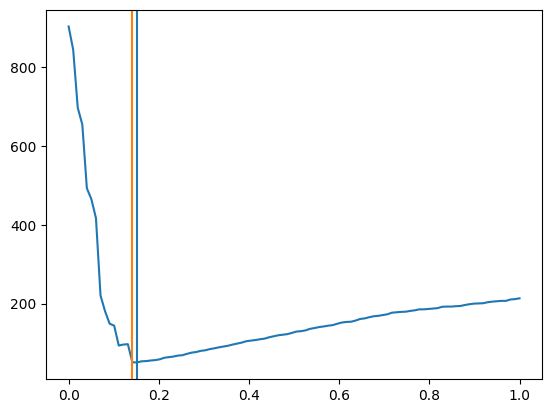

In [39]:
from tqdm.auto import tqdm

eps = 1e-14

cache_a = make_cache(a, b)
cache_b = make_cache(b, a)

lambdas = np.linspace(0, 1, 100)

rankings_a = []
rankings_b = []
rankings_combined = []
for lambda_ in tqdm(lambdas):
#     score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
#     rankings.append(np.argsort(-score).tolist().index(j))

    score_a = npmi_batch_popularity_weighted(mat, a, lambda_, cache=cache_a, eps=eps)
    score_b = npmi_batch_popularity_weighted(mat, b, lambda_, cache=cache_b, eps=eps)
    
    rankings_a.append(np.argsort(-score_a).tolist().index(b))
    rankings_b.append(np.argsort(-score_b).tolist().index(a))
    rankings_combined.append((rankings_a[-1] + rankings_b[-1])/2)

# min(np.diff(rankings))

import matplotlib.pyplot as plt

rankings = rankings_combined

plt.plot(lambdas, rankings);
plt.axvline(lambdas[np.argmin(rankings)]);
plt.axvline(.14, c="tab:orange");

In [32]:
lambdas[np.argmin(rankings)]

np.float64(0.15151515151515152)

In [33]:
min(rankings)

50.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
a_to_b_error_metric_npmi_pop_weighted(artist_mat, a, b, lambda_)

lambda_: 0.13408607326731756
error: 47.5


47.5

In [396]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
#     py = (py * o) + (.5 * (1 - o))
#     px = (px * o) + (.5 * (1 - o))
#     pxy = (pxy * o) + (.5**2 * (1 - o))
#     pxy = (pxy * o) + ((px * py) * (1 - o))

#     px = py = np.where(px > py, px, py)
    px = py = (px + py)/2
#     px = py = px + py

#     px = np.where(px > py, px, py)
#     px = (px + py)/2
#     px = px + py
    
#     py = np.where(px > py, px, py)
#     py = (px + py)/2
#     py = px + py

#     py = np.where(px < py, px, py)
    score = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)

    if call_again:
        return (metric(j, i, o, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [397]:
metric(a, b, .6)

98.5

In [267]:
metric(a, b, .11)

105.0

In [246]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Quiet Arrows (spotify:artist:7KRnRH8bRvoX4ebQwHw2EI)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'This, the Silent War (spotify:artist:3156bBfcG5gFSWrftU8gaR)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Josh Jenkins (spotify:artist:20nyUQUh2kYdqOauF3y3Pu)',
 'Choir Of Young Believers (spotify:artist:4aXPrNXYJLziXeH7Obkea7)',
 'Samaris (spotify:artist:1Xl5hsislt88ijOD3EZsOY)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Adurn (spotify:artist:4hDzPWJ7vNSD2wCEF49w8r)',
 'Joe Banfi (spotify:artist:5XuI2JDHF

In [37]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [33]:
top_k = 20

In [34]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, a, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)',
 'Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)',
 'Mikkel Øwre (spotify:artist:1kNHqkERzDBPrzdK9DogGQ)',
 'Pieces of Juno (spotify:artist:1k88AWvVVqKbz6C0kK624d)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'A-Laget (spotify:artist:2eJz0fbC9ZqBL3mGWPBvI5)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Carl Louis (spotify:artist:5LY4Rzduoz5b0qZdV3rHwK)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Morten Myklebust (spotify:artist:7zFc6IlzgDwyXoj

In [35]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, b, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)',
 'The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'Low Volts (spotify:artist:3PxUwSSsVaW0XyBiRJF2oS)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Panama (spotify:artist:3W9UldYu0xJcaOA